# Algorytm Symulowanej Bifurkacji



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from typing import Optional, Callable, Union



def simulated_bifurcation(J, h, num_steps, time_step, M, trajectories, 
                          K: Optional[float] = None, delta: Optional[float] = None, xi_0: Union[Callable, float, None] = None):
    # Ustawianie parametrów
    K = 1
    delta = 1
    small_delta_t = time_step/M
    N = len(h)
    sigma = 1   # sigma = np.std(J.flatten())
    xi_0 = 0.7 * time_step / sigma * sqrt(N)
    #xi_0 = 0.1
   
    # Iniclizacja
    # x = np.random.uniform(-0.1, 0.1, (N, trajectories))
    x = np.zeros((N, trajectories))
    y = np.random.uniform(-0.1, 0.1, (N, trajectories))
    #y = np.zeros((N, trajectories))
    p = np.linspace(0, 1, num=num_steps)

    x_1_history = []
    y_1_history = []
    timeline = np.array(list(range(num_steps)))

    for t in range(num_steps):
        x += delta * y * time_step
        y -= (K * np.power(x, 3) + (delta - p[t]) * x - xi_0 * J @ x) * time_step

        # x_m = x
        # y_m = y

        # for _ in range(M):
        #     x_m += delta * y_m * small_delta_t
        #     y_m -= (K * np.power(x_m, 3) + (delta - p[t + 1]) * x_m) * small_delta_t

        # x = x_m
        # y = y_m + xi_0 * J @ x * time_step
        x_1_history.append(x[0, 0])
        y_1_history.append(y[0, 0])
        

    
    plt.plot(timeline, x_1_history)
    plt.plot(timeline, y_1_history)
    plt.ylim(-1.5, 1.5)
    plt.legend(["x_i", "y_i"])
    plt.xlabel("t")
    plt.show()
    solution = np.sign(x)
    return solution, -0.5 * solution.T @ J @ solution

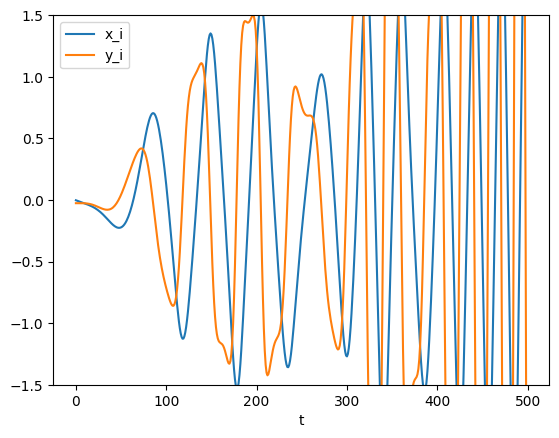

[[-7.]]


In [5]:
from funkcje_pomocnicze import read_instance, small_pegasus
J, h = read_instance(small_pegasus.path)
nstep = 500
time_step = 0.1
M = 4

_, energy = simulated_bifurcation(J, h, nstep, time_step, M, 1)

print(energy)

# Inne wersje Symulowanej Bifurkacji

## Balistyczna Symulowana Bifurkacja

In [4]:
# Implementacja Balistycznej Symulowanej Bifurkacji
import numpy as np

from math import sqrt
from typing import Optional
from tqdm import tqdm

from funkcje_pomocnicze import calculate_energy_matrix

#TODO: Napisać efektywniej
def wall(x:np.ndarray, y:np.ndarray):
    n, m = x.shape
    for i in range(n):
        for j in range(m):
            if abs(x[i, j]) > 1:
                x[i, j] = np.sign(x[i, j])
                y[i, j] = 0
    return x, y


def balistic_simulated_bifurcation(J, h, num_steps, time_step, num_trajectories: int, 
                                   a_0: Optional[float] = None, c_0_scaling: Optional[float] = None):
    if a_0 is None:
        a_0 = 1

    N, _ = J.shape
    mean_J = np.sqrt(np.sum(np.square(J)) / (N * (N - 1)) )
    c_0 = 0.5 / (mean_J * sqrt(N))

    if c_0_scaling is not None:
        c_0 *= c_0_scaling


    a = np.linspace(0, a_0, num=num_steps)

    x = np.zeros((N, num_trajectories))
    y = np.random.uniform(-0.1, 0.1, (N, num_trajectories))

    for t in tqdm(range(num_steps), desc="Symulowana Bifurkacja"):
        y += (-1 * (a_0 - a[t]) * x + c_0 * (J @ x + h.reshape((N, 1)))) * time_step  # x(t)
        x += a_0 * y * time_step # x(t + 1)

        x, y = wall(x, y)

    x = np.sign(x)
    return x, calculate_energy_matrix(J, h, x)



Symulowana Bifurkacja: 100%|██████████| 200/200 [00:33<00:00,  6.05it/s]

Otrzymana energia: -467.0
Stan podstawowy: -469.0


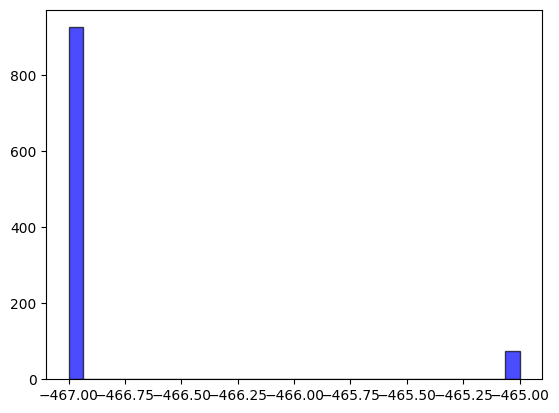

In [3]:
import matplotlib.pyplot as plt
from funkcje_pomocnicze import read_instance, test_pegasus

J, h = read_instance(test_pegasus.path, convention="minus_half")

states, energies = balistic_simulated_bifurcation(J, h, num_steps=200, time_step=0.5, num_trajectories=1000, a_0=1, c_0_scaling=0.7)

print(f"Otrzymana energia: {min(energies)}")
print(f"Stan podstawowy: {test_pegasus.best_energy}")


plt.hist(energies, bins=32, color='blue', edgecolor='black', alpha=0.7)
plt.show()


## Dyskretna Symulowana Bifurkacja

In [21]:
# Implementacja Balistycznej Symulowanej Bifurkacji
import numpy as np

from math import sqrt
from typing import Optional
from tqdm import tqdm

from funkcje_pomocnicze import calculate_energy_matrix


def discrete_simulated_bifurcation(J, h, num_steps, time_step, num_trajectories: int, 
                                   a_0: Optional[float] = None, c_0_scaling: Optional[float] = None):
    if a_0 is None:
        a_0 = 1

    N, _ = J.shape
    mean_J = np.sqrt(np.sum(np.square(J)) / (N * (N - 1)) )
    c_0 = 0.5 / (mean_J * sqrt(N))

    if c_0_scaling is not None:
        c_0 *= c_0_scaling
        
    a = np.linspace(0, a_0, num=num_steps)

    x = np.zeros((N, num_trajectories))
    y = np.random.uniform(-0.1, 0.1, (N, num_trajectories))

    for t in tqdm(range(num_steps), desc="Symulowana Bifurkacja"):
        y += (-1 * (a_0 - a[t]) * x + c_0 * (J @ np.sign(x) + h.reshape((N, 1)))) * time_step  # y(t+1); x(t), x(t)
        x += a_0 * y * time_step # x(t + 1); y(t+1)

        x, y = wall(x, y)

    x = np.sign(x)
    return x, calculate_energy_matrix(J, h, x)


Symulowana Bifurkacja:   0%|          | 0/200 [00:00<?, ?it/s]

Symulowana Bifurkacja: 100%|██████████| 200/200 [00:35<00:00,  5.62it/s]

Otrzymana energia: -469.0
Stan podstawowy: -469.0


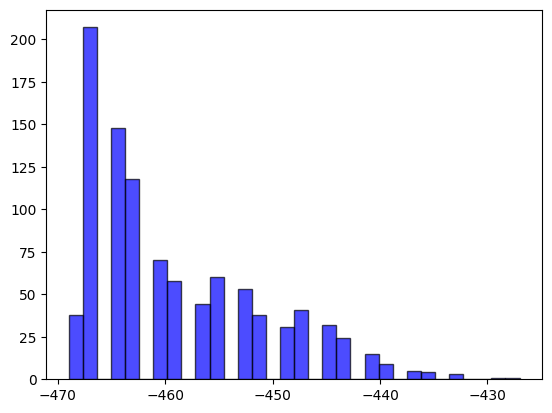

In [22]:
from funkcje_pomocnicze import read_instance, test_pegasus

J, h = read_instance(test_pegasus.path, convention="minus_half")

states, energies = discrete_simulated_bifurcation(J, h, num_steps=200, time_step=0.5, num_trajectories=1000, a_0=1, c_0_scaling=0.7)

print(f"Otrzymana energia: {min(energies)}")
print(f"Stan podstawowy: {test_pegasus.best_energy}")


plt.hist(energies, bins=32, color='blue', edgecolor='black', alpha=0.7)
plt.show()

# Bibliografia

* Hayato Goto *et al.*, Combinatorial optimization by simulating adiabatic bifurcations in nonlinear Hamiltonian systems. *Sci. Adv.* **5**, eaav2372 (2019). DOI:[10.1126/sciadv.aav2372](https://www.science.org/doi/10.1126/sciadv.aav2372)

* Hayato Goto *et al.*, High-performance combinatorial optimization based on classical mechanics. *Sci. Adv.* **7**, eabe7953 (2021).   
DOI:[10.1126/sciadv.abe7953](https://www.science.org/doi/10.1126/sciadv.abe7953)